# **F1 Audiovisual RAG System**

This notebook demonstrates a sophisticated Retrieval-Augmented Generation (RAG) system that combines visual and audio information from Formula 1 videos to generate dynamic commentary. It utilizes several powerful AI models:

- **`yt-dlp`**: For downloading YouTube videos.
- **`OpenCV`**: For video frame extraction.
- **`CLIP (Contrastive Language-Image Pre-training)`**: To generate visual embeddings from video frames and text queries, enabling semantic search on visual content.
- **`CLAP (Contrastive Language-Audio Pre-training)`**: To generate audio embeddings from audio segments and text queries, enabling semantic search on audio content.
- **`FAISS`**: For efficient similarity search on both visual and audio embeddings.
- **`LLaVA (Large Language and Vision Assistant)`**: A multimodal Large Language Model (VLM) for interpreting visual frames and extracting structured information (clinical JSON).
- **`Groq Llama-3`**: A powerful LLM used to transform the clinical JSON data into engaging, persona-driven Formula 1 commentary.

The system works by:
1.  Downloading F1 videos.
2.  Extracting frames and audio segments from these videos.
3.  Generating embeddings for both visual frames (using CLIP) and audio segments (using CLAP).
4.  Indexing these embeddings using FAISS for rapid retrieval.
5.  Performing a multimodal search based on a text query, fusing visual and audio search results.
6.  Using the LLaVA model to analyze the most relevant video frames and extract key events into a structured JSON format.
7.  Finally, employing a Groq-powered Llama-3 model to generate enthusiastic, F1-style commentary based on the extracted JSON.

This project showcases a complete pipeline for building intelligent, context-aware RAG systems for rich media content.

# **1. Install Dependencies**

First, we install `yt-dlp` to download YouTube videos, which will serve as our raw data source. This is a command-line program to download videos and audio from YouTube and other sites.

In [1]:
!pip install yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.3/182.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 59.7 MB/s eta 0:00:00


# **2. Download F1 Videos**

In this section, we download several Formula 1 videos from YouTube. These videos cover various aspects of F1 races, such as general race footage, Monaco Grand Prix highlights, race starts, pit stops, and crashes. We explicitly force the download format to MP4 and rename the files for consistency and easier access.

**Data Source**: YouTube F1 channels.

**Results**: Several MP4 video files stored in the `/content/` directory, named descriptively (e.g., `f1_sample.mp4`, `f1_monaco.mp4`).

In [2]:
# Run this in the second cell
# We force it to download as an mp4 and rename it to 'f1_sample.mp4'
!yt-dlp -f "mp4" -o "/content/f1_sample.mp4" "https://youtu.be/FE5FGSEQc8Q?si=HaI-UzfOsJvC1c5y"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/FE5FGSEQc8Q?si=HaI-UzfOsJvC1c5y
[youtube] FE5FGSEQc8Q: Downloading webpage
[youtube] FE5FGSEQc8Q: Downloading android vr player API JSON
[info] FE5FGSEQc8Q: Downloading 1 format(s): 18
[download] Destination: /content/f1_sample.mp4
[download] 100% of   14.75MiB in 00:00:00 at 29.46MiB/s


In [3]:
!yt-dlp -f "mp4" -o "/content/f1_monaco.mp4" "https://youtu.be/ajzQj7bjSWE?si=_xYy-3GfnWANR4yo"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/ajzQj7bjSWE?si=_xYy-3GfnWANR4yo
[youtube] ajzQj7bjSWE: Downloading webpage
[youtube] ajzQj7bjSWE: Downloading android vr player API JSON
[info] ajzQj7bjSWE: Downloading 1 format(s): 18
[download] Destination: /content/f1_monaco.mp4
[download] 100% of   42.11MiB in 00:00:02 at 19.65MiB/s


In [4]:
!yt-dlp -f "mp4" -o "/content/f1_starts.mp4" "https://youtu.be/WtlHPTO0VDM?si=6MC9LTaMCObf2rVh"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/WtlHPTO0VDM?si=6MC9LTaMCObf2rVh
[youtube] WtlHPTO0VDM: Downloading webpage
[youtube] WtlHPTO0VDM: Downloading android vr player API JSON
[info] WtlHPTO0VDM: Downloading 1 format(s): 18
[download] Destination: /content/f1_starts.mp4
[download] 100% of   46.44MiB in 00:00:02 at 16.16MiB/s


In [5]:
!yt-dlp -f "mp4" -o "/content/f1_crashes.mp4" "https://youtu.be/vWxG8hZjl_g?si=5yCxoh8p2t6BI5FC"

         Pre-merged mp4 formats are not available from all sites, or may only be available in lower quality.
         To prioritize the best h264 video and aac audio in an mp4 container, use "-t mp4" instead.
         If you know what you are doing and want a pre-merged mp4 format, use "-f b[ext=mp4]" instead to suppress this warning
[youtube] Extracting URL: https://youtu.be/vWxG8hZjl_g?si=5yCxoh8p2t6BI5FC
[youtube] vWxG8hZjl_g: Downloading webpage
[youtube] vWxG8hZjl_g: Downloading android vr player API JSON
[info] vWxG8hZjl_g: Downloading 1 format(s): 18
[download] Destination: /content/f1_crashes.mp4
[download] 100% of   21.83MiB in 00:00:01 at 13.94MiB/s


# **3. Define Frame Extraction Function**

Here, we define a helper function `extract_frames_1fps` that uses `OpenCV` to process video files. The goal is to extract one frame per second from each video. This downsampling is crucial for managing computational resources and focusing on significant visual changes rather than redundant frames.

**Libraries Used**: `cv2` (OpenCV) for video processing and `pathlib` for directory management.

**Process**: The function opens a video, reads its frames, and saves one frame every second as a JPEG image in a specified output directory. It also includes logging to track progress.

**Intermediate Output**: JPEG image files (e.g., `frame_0000.jpg`) within `/content/data/frames`.

In [6]:
# Run this in the third cell
import cv2
import os
from pathlib import Path

def extract_frames_1fps(video_path, output_dir):
    """
    Extracts 1 frame per second and saves them to the Colab filesystem.
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Error opening video file: {video_path}")

    fps = round(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames // fps

    print(f"Video loaded. Original FPS: {fps} | Duration: {duration_sec} seconds")
    print(f"Extracting to '{output_dir}'...")

    current_frame = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Target one frame for every 'fps' chunk
        if current_frame % fps == 0:
            timestamp_sec = current_frame // fps
            filename = f"frame_{timestamp_sec:04d}.jpg"
            filepath = os.path.join(output_dir, filename)

            cv2.imwrite(filepath, frame)
            saved_count += 1

            if timestamp_sec % 30 == 0 and timestamp_sec > 0:
                print(f"Processed up to {timestamp_sec} seconds...")

        current_frame += 1

    cap.release()
    print(f"Extraction complete! {saved_count} frames saved.")

# Execute the function
VIDEO_FILE = "/content/f1_sample.mp4"
OUTPUT_FOLDER = "/content/data/frames"

extract_frames_1fps(VIDEO_FILE, OUTPUT_FOLDER)

Video loaded. Original FPS: 25 | Duration: 193 seconds
Extracting to '/content/data/frames'...
Processed up to 30 seconds...
Processed up to 60 seconds...
Processed up to 90 seconds...
Processed up to 120 seconds...
Processed up to 150 seconds...
Processed up to 180 seconds...
Extraction complete! 194 frames saved.


# **4. Test Frame Extraction (Optional View)**

This cell demonstrates how to load and display a specific extracted frame to verify the `extract_frames_1fps` function is working correctly. It uses `cv2_imshow` from `google.colab.patches` to show the image directly in the notebook output.

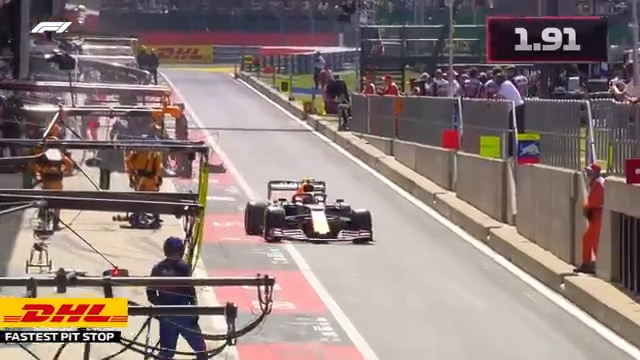

In [7]:
# Run this in the fourth cell to view the frame at the 10-second mark
from google.colab.patches import cv2_imshow
import cv2

# Load and display a specific frame
test_frame_path = "/content/data/frames/frame_0010.jpg"
if os.path.exists(test_frame_path):
    img = cv2.imread(test_frame_path)
    # Resize it slightly so it doesn't blow up the notebook output
    img_resized = cv2.resize(img, (640, 360))
    cv2_imshow(img_resized)
else:
    print("Frame not found. Check the output directory.")

# **5. Extract Frames from All Videos**

This section applies the `extract_frames_1fps` function to all downloaded F1 videos. Each video's frames are stored in the `/content/data/frames` directory, with filenames prefixed by the video identifier (e.g., `v1_crashes_frame_0000.jpg`). This ensures unique identification of frames across different videos.

**Data**: All previously downloaded F1 videos.

**Output**: Thousands of individual JPEG frames, each representing one second of video content, saved into `/content/data/frames`.

In [8]:
import cv2
import os
import glob
from pathlib import Path

def extract_frames_1fps(video_path, output_dir, video_prefix):
    """
    Extracts 1 frame per second and saves them with a unique video prefix.
    """
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Skipping {video_path}: Could not open video.")
        return

    fps = round(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration_sec = total_frames // fps if fps > 0 else 0

    print(f"\nProcessing '{video_prefix}' | Original FPS: {fps} | Duration: {duration_sec} seconds")

    current_frame = 0
    saved_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Target one frame for every 'fps' chunk
        if fps > 0 and current_frame % fps == 0:
            timestamp_sec = current_frame // fps

            # UNIQUE FILENAME: e.g., v1_pitstops_frame_0042.jpg
            filename = f"{video_prefix}_frame_{timestamp_sec:04d}.jpg"
            filepath = os.path.join(output_dir, filename)

            cv2.imwrite(filepath, frame)
            saved_count += 1

            if timestamp_sec % 60 == 0 and timestamp_sec > 0:
                print(f"  -> Extracted up to {timestamp_sec} seconds...")

        current_frame += 1

    cap.release()
    print(f"Finished '{video_prefix}'! {saved_count} frames saved.")

# --- Execution for Multiple Videos ---
OUTPUT_FOLDER = "/content/data/frames"

# Create a dictionary mapping the video path to a short prefix name
video_files = {
    "/content/f1_crashes.mp4": "v1_crashes",
    "/content/f1_monaco.mp4": "v2_monaco",
    "/content/f1_sample.mp4": "v3_pit",
    "/content/f1_starts.mp4": "v4_starts"
}

# Loop through and process all of them
for video_path, prefix in video_files.items():
    # Only process if the file actually exists in your Colab environment
    if os.path.exists(video_path):
        extract_frames_1fps(video_path, OUTPUT_FOLDER, prefix)
    else:
        print(f"Warning: {video_path} not found. Did you download it?")


Processing 'v1_crashes' | Original FPS: 25 | Duration: 361 seconds
  -> Extracted up to 60 seconds...
  -> Extracted up to 120 seconds...
  -> Extracted up to 180 seconds...
  -> Extracted up to 240 seconds...
  -> Extracted up to 300 seconds...
  -> Extracted up to 360 seconds...
Finished 'v1_crashes'! 362 frames saved.

Processing 'v2_monaco' | Original FPS: 25 | Duration: 492 seconds
  -> Extracted up to 60 seconds...
  -> Extracted up to 120 seconds...
  -> Extracted up to 180 seconds...
  -> Extracted up to 240 seconds...
  -> Extracted up to 300 seconds...
  -> Extracted up to 360 seconds...
  -> Extracted up to 420 seconds...
  -> Extracted up to 480 seconds...
Finished 'v2_monaco'! 493 frames saved.

Processing 'v3_pit' | Original FPS: 25 | Duration: 193 seconds
  -> Extracted up to 60 seconds...
  -> Extracted up to 120 seconds...
  -> Extracted up to 180 seconds...
Finished 'v3_pit'! 194 frames saved.

Processing 'v4_starts' | Original FPS: 25 | Duration: 713 seconds
  -> Ex

# **6. Install Transformers for CLIP**

We install the `transformers` library from Hugging Face, which provides pre-trained models like CLIP, and `faiss-cpu` for efficient similarity search. We install it quietly (`-q`).

In [9]:
# Run this in a new cell
!pip install -q transformers

# **7. Generate Visual Embeddings with CLIP**

This crucial step involves generating high-dimensional vector representations (embeddings) for each extracted video frame using the `CLIP (Contrastive Language-Image Pre-training)` model. CLIP is a powerful model capable of understanding both images and text, making it ideal for multimodal search.

**Model Used**: `openai/clip-vit-base-patch32` from Hugging Face Transformers.

**Process**: Frames are loaded in batches, preprocessed by the CLIP processor, and then fed into the CLIP model's vision transformer to obtain image features. These features are then L2-normalized, which is essential for cosine similarity calculations later.

**Output**: A `frame_embeddings.pkl` file containing a dictionary with `filenames` (list of frame paths) and `embeddings` (a NumPy array where each row is the 512-dimensional embedding for a corresponding frame). This file is stored in `/content/data/`.

In [10]:
import os
import torch
import pickle
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm
from transformers import CLIPProcessor, CLIPModel

# 1. Setup paths and device
FRAMES_DIR = "/content/data/frames"
OUTPUT_EMBEDDINGS_FILE = "/content/data/frame_embeddings.pkl"
BATCH_SIZE = 64  # Colab T4 GPUs handle this easily

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device.upper()}")

# 2. Load the CLIP model and processor
print("Loading CLIP model (this might take a few seconds)...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)
model.eval() # Set to evaluation mode

# 3. Gather all frame paths
all_frames = sorted([
    f for f in os.listdir(FRAMES_DIR)
    if f.endswith(".jpg") or f.endswith(".png")
])

print(f"Found {len(all_frames)} frames to process.")

# 4. Extract Embeddings in Batches
all_embeddings = []
all_filenames = []

# Wrap in torch.no_grad() to save massive amounts of memory
# Wrap in torch.no_grad() to save massive amounts of memory
with torch.no_grad():
    for i in tqdm(range(0, len(all_frames), BATCH_SIZE), desc="Extracting Batches"):
        # Slice the current batch of filenames
        batch_filenames = all_frames[i : i + BATCH_SIZE]
        batch_filepaths = [os.path.join(FRAMES_DIR, f) for f in batch_filenames]

        # Load images using PIL
        images = [Image.open(fp).convert("RGB") for fp in batch_filepaths]

        # Preprocess images (resize, normalize) and move to GPU
        inputs = processor(images=images, return_tensors="pt").to(device)

        # Pass through the Vision Transformer
        outputs = model.get_image_features(**inputs)

        # --- THE FIX: Extract the raw tensor if it's wrapped in an object ---
        if not isinstance(outputs, torch.Tensor):
            if hasattr(outputs, "image_embeds"):
                image_features = outputs.image_embeds
            elif hasattr(outputs, "pooler_output"):
                # If we got the raw vision output, project it manually to 512-dim
                # Check if pooler_output needs projection or is already projected
                if outputs.pooler_output.shape[-1] == model.visual_projection.in_features:
                    # This is the raw vision output (e.g., 768-dim), project it
                    image_features = model.visual_projection(outputs.pooler_output)
                elif outputs.pooler_output.shape[-1] == model.visual_projection.out_features:
                    # This is already the projected embedding (e.g., 512-dim), use directly
                    image_features = outputs.pooler_output
                else:
                    # Fallback for unexpected dimensions or handle as an error
                    print(f"Warning: Unexpected pooler_output dimension ({outputs.pooler_output.shape[-1]}). Using it as is.")
                    image_features = outputs.pooler_output
            else:
                image_features = outputs[0]
        else:
            image_features = outputs # It was already a tensor

        # Normalize the embeddings (Crucial for Cosine Similarity in Phase 3)
        image_features = image_features / image_features.norm(p=2, dim=-1, keepdim=True)

        # Move back to CPU and convert to numpy
        all_embeddings.append(image_features.cpu().numpy())
        all_filenames.extend(batch_filenames)


# 5. Concatenate and Save
if all_embeddings:
    final_embeddings_matrix = np.vstack(all_embeddings)

    # Save as a dictionary linking the filename to its vector
    data_to_save = {
        "filenames": all_filenames,
        "embeddings": final_embeddings_matrix
    }

    with open(OUTPUT_EMBEDDINGS_FILE, "wb") as f:
        pickle.dump(data_to_save, f)

    print(f"\nSuccess! Extracted matrix shape: {final_embeddings_matrix.shape}")
    print(f"Saved to: {OUTPUT_EMBEDDINGS_FILE}")
else:
    print("No embeddings were extracted. Check if the frames directory is empty.")

Using device: CUDA
Loading CLIP model (this might take a few seconds)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Found 1957 frames to process.


Extracting Batches:   0%|          | 0/31 [00:00<?, ?it/s]


Success! Extracted matrix shape: (1957, 512)
Saved to: /content/data/frame_embeddings.pkl


# **8. Install FAISS for Visual Indexing**

Here, we install `faiss-cpu`, a library for efficient similarity search and clustering of dense vectors. This will be used to quickly find frames that are visually similar to a given text query.

In [11]:
# Run this in a new cell
!pip install -q faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 95.9 MB/s eta 0:00:00


# **9. Build FAISS Index and Implement Visual Search & Clustering**

This section sets up the FAISS index for our visual embeddings and defines the core `search_and_cluster` function. This function performs a semantic search using CLIP's text encoder to generate a query embedding, then uses FAISS to find the most visually relevant frames. It also includes a temporal clustering algorithm to group nearby frames into coherent video segments, making the results more useful.

**Models/Libraries Used**:
- `CLIPModel` and `CLIPProcessor`: For encoding text queries into the same embedding space as images.
- `FAISS` (`IndexFlatIP`): For ultra-fast nearest neighbor search on the normalized CLIP embeddings. Inner Product (IP) is used because L2-normalized vectors' dot product is equivalent to cosine similarity.

**Process**:
1.  Loads the pre-computed visual embeddings and filenames.
2.  Initializes an `IndexFlatIP` FAISS index with the correct dimension (512 for CLIP embeddings) and adds all frame embeddings to it.
3.  The `search_and_cluster` function takes a text query, encodes it, searches the FAISS index for `top_k` similar frames, and then groups these frames into contiguous video clips if they are within a `merge_threshold` (in seconds). Padding is added to clip boundaries for better context.

**Results**: The FAISS index is built and ready for queries. The `search_and_cluster` function returns a list of dictionaries, each describing a video segment with `video` ID, `start` time, and `end` time.

In [12]:
import faiss
import pickle
import torch
import numpy as np
from transformers import CLIPProcessor, CLIPModel

# 1. Configuration
EMBEDDINGS_FILE = "/content/data/frame_embeddings.pkl"
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the same CLIP model to encode our text queries
print("Loading Text Encoder...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id).to(device)
processor = CLIPProcessor.from_pretrained(model_id)
model.eval()

# 2. Load the Visual Memory (Embeddings)
print("Loading frame embeddings...")
with open(EMBEDDINGS_FILE, "rb") as f:
    data = pickle.load(f)

filenames = data["filenames"]
embeddings = np.array(data["embeddings"], dtype=np.float32)

# 3. Initialize FAISS Index
# We use IndexFlatIP (Inner Product) because our vectors are already L2 normalized.
# Inner Product on normalized vectors is mathematically identical to Cosine Similarity.
dimension = embeddings.shape[1] # Should be 512 for CLIP
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)
print(f"FAISS Index built! Total frames indexed: {index.ntotal}")

# 4. The Temporal Clustering Algorithm
def search_and_cluster(query_text, top_k=20, merge_threshold=5, padding=2):
    """
    Searches the FAISS index and clusters nearby frames into video segments.
    """
    # A. Encode the text query
    inputs = processor(text=[query_text], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features_output = model.get_text_features(**inputs)

        # --- THE FIX: Extract the raw tensor if it's wrapped in an object ---
        if not isinstance(text_features_output, torch.Tensor):
            if hasattr(text_features_output, "text_embeds"): # Specific for text embeddings
                text_features_tensor = text_features_output.text_embeds
            elif hasattr(text_features_output, "pooler_output"): # General pooled output
                text_features_tensor = text_features_output.pooler_output
            else:
                # Fallback, assuming the first element is the tensor if it's a tuple-like object
                text_features_tensor = text_features_output[0]
        else:
            text_features_tensor = text_features_output # It was already a tensor

        # Normalize text vector
        text_features_normalized = text_features_tensor / text_features_tensor.norm(p=2, dim=-1, keepdim=True)
        text_vector = text_features_normalized.cpu().numpy().astype(np.float32)

    # B. Search FAISS
    distances, indices = index.search(text_vector, top_k)

    # C. Parse results into a structured list
    raw_results = []
    for dist, idx in zip(distances[0], indices[0]):
        filename = filenames[idx]
        # Filename format: v1_crashes_frame_0042.jpg
        # Split logic to extract video name and timestamp safely
        parts = filename.split("_frame_")
        if len(parts) == 2:
            video_prefix = parts[0]
            timestamp = int(parts[1].split(".")[0])
            raw_results.append({"video": video_prefix, "time": timestamp, "score": float(dist)})

    # D. Cluster the frames chronologically
    # Group by video first
    video_groups = {}
    for res in raw_results:
        vid = res["video"]
        if vid not in video_groups:
            video_groups[vid] = []
        video_groups[vid].append(res["time"])

    final_clips = []

    for vid, times in video_groups.items():
        times = sorted(times)

        # Start the first cluster
        current_cluster = [times[0]]

        for i in range(1, len(times)):
            # If the next frame is within the threshold, add it to the cluster
            if times[i] - current_cluster[-1] <= merge_threshold:
                current_cluster.append(times[i])
            else:
                # Save the completed cluster and start a new one
                start_time = max(0, current_cluster[0] - padding)
                end_time = current_cluster[-1] + padding
                final_clips.append({"video": vid, "start": start_time, "end": end_time})
                current_cluster = [times[i]]

        # Save the final cluster in the loop
        start_time = max(0, current_cluster[0] - padding)
        end_time = current_cluster[-1] + padding
        final_clips.append({"video": vid, "start": start_time, "end": end_time})

    return final_clips

print("Clustering engine ready!")

Loading Text Encoder...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading frame embeddings...
FAISS Index built! Total frames indexed: 1957
Clustering engine ready!


# **10. Test Visual Search Engine**

This cell demonstrates the visual search capability by running several example queries. It shows how the `search_and_cluster` function identifies relevant video clips based purely on visual content, using the CLIP embeddings and FAISS index.

**Queries Tested**:
- "A formula one car spinning out and crashing"
- "Mechanics changing tires during a pit stop"
- "Five red lights turning off at the race start"

**Results**: For each query, a list of identified video clips is printed, indicating the video source (e.g., `v1_crashes`) and the start/end times in seconds. This confirms the visual RAG system is successfully retrieving semantically relevant segments.

In [13]:
# Run this cell to test your engine
queries_to_test = [
    "A formula one car spinning out and crashing",
    "Mechanics changing tires during a pit stop",
    "Five red lights turning off at the race start"
]

for query in queries_to_test:
    print(f"\n🔍 Query: '{query}'")
    clips = search_and_cluster(query, top_k=15, merge_threshold=4, padding=2)

    if not clips:
        print("No matches found.")
    else:
        for i, clip in enumerate(clips):
            print(f"  🎬 Clip {i+1}: [{clip['video']}] from {clip['start']}s to {clip['end']}s")


🔍 Query: 'A formula one car spinning out and crashing'
  🎬 Clip 1: [v1_crashes] from 315s to 319s
  🎬 Clip 2: [v1_crashes] from 340s to 344s
  🎬 Clip 3: [v4_starts] from 126s to 130s
  🎬 Clip 4: [v4_starts] from 271s to 275s
  🎬 Clip 5: [v4_starts] from 288s to 294s
  🎬 Clip 6: [v4_starts] from 417s to 426s
  🎬 Clip 7: [v4_starts] from 542s to 546s
  🎬 Clip 8: [v4_starts] from 556s to 560s
  🎬 Clip 9: [v4_starts] from 623s to 627s
  🎬 Clip 10: [v4_starts] from 699s to 703s
  🎬 Clip 11: [v2_monaco] from 199s to 203s

🔍 Query: 'Mechanics changing tires during a pit stop'
  🎬 Clip 1: [v1_crashes] from 106s to 110s
  🎬 Clip 2: [v1_crashes] from 111s to 115s
  🎬 Clip 3: [v3_pit] from 6s to 13s
  🎬 Clip 4: [v3_pit] from 117s to 121s
  🎬 Clip 5: [v2_monaco] from 169s to 174s
  🎬 Clip 6: [v2_monaco] from 230s to 240s
  🎬 Clip 7: [v2_monaco] from 383s to 387s

🔍 Query: 'Five red lights turning off at the race start'
  🎬 Clip 1: [v4_starts] from 16s to 20s
  🎬 Clip 2: [v4_starts] from 119s to 1

# **11. Install Audio Processing Libraries**

We install `moviepy` for video and audio editing, `librosa` for audio analysis, and `transformers` for the CLAP model. These are crucial for extracting and processing audio from the F1 videos.

In [14]:
!pip install -q moviepy librosa transformers

# **12. Generate Audio Embeddings with CLAP**

Similar to visual embeddings, this section generates high-dimensional vector representations for 1-second audio chunks using the `CLAP (Contrastive Language-Audio Pre-training)` model. CLAP understands both audio and text, enabling semantic search on sound content.

**Model Used**: `laion/clap-htsat-unfused` from Hugging Face Transformers.

**Process**:
1.  For each downloaded F1 video, its audio track is extracted using `moviepy`.
2.  The audio is then loaded with `librosa` and chunked into 1-second segments.
3.  Each 1-second audio chunk is processed by the CLAP processor and fed into the CLAP model to obtain audio features. These features are then L2-normalized.

**Output**: An `audio_embeddings.pkl` file containing a dictionary with `filenames` (list of audio chunk identifiers) and `embeddings` (a NumPy array where each row is the 512-dimensional embedding for a corresponding audio chunk). This file is stored in `/content/data/`.

In [15]:
import os
import torch
import librosa
import pickle
import numpy as np
from moviepy.editor import VideoFileClip
from transformers import ClapModel, ClapProcessor
from tqdm.notebook import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
AUDIO_OUTPUT_DIR = "/content/data/audio_chunks"
os.makedirs(AUDIO_OUTPUT_DIR, exist_ok=True)

# 1. Load CLAP
print("Loading CLAP Audio Model...")
clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")
clap_model.eval()

# 2. Extract and Chunk Audio
video_files = {
    "/content/f1_crashes.mp4": "v1_crashes",
    "/content/f1_monaco.mp4": "v2_monaco",
    "/content/f1_sample.mp4": "v3_pit",
    "/content/f1_starts.mp4": "v4_starts"
}

audio_embeddings = []
audio_filenames = []

with torch.no_grad():
    for vid_path, prefix in video_files.items():
        if not os.path.exists(vid_path):
            continue

        print(f"\nProcessing Audio for: {prefix}")
        video = VideoFileClip(vid_path)

        # Extract audio to a temporary file
        temp_audio_path = f"/content/{prefix}_full.wav"
        video.audio.write_audiofile(temp_audio_path, logger=None, fps=48000)

        # Load with librosa
        y, sr = librosa.load(temp_audio_path, sr=48000)
        duration = int(librosa.get_duration(y=y, sr=sr))

        # Chunk into 1-second slices to match our 1 FPS visual frames
        for sec in tqdm(range(duration), desc=f"Embedding {prefix}"):
            start_sample = sec * sr
            end_sample = (sec + 1) * sr
            chunk = y[start_sample:end_sample]

            if len(chunk) < sr / 2: # Skip tiny fragments at the end
                continue

            # Run through CLAP
            inputs = clap_processor(audio=chunk, sampling_rate=sr, return_tensors="pt").to(device)
            features_output = clap_model.get_audio_features(**inputs)

            # --- THE FIX: Extract the raw tensor if it's wrapped in an object ---
            if not isinstance(features_output, torch.Tensor):
                if hasattr(features_output, "audio_embeds"): # Specific for audio embeddings
                    features_tensor = features_output.audio_embeds
                elif hasattr(features_output, "pooler_output"): # General pooled output
                    features_tensor = features_output.pooler_output
                else:
                    # Fallback, assuming the first element is the tensor if it's a tuple-like object
                    features_tensor = features_output[0]
            else:
                features_tensor = features_output # It was already a tensor

            features_normalized = features_tensor / features_tensor.norm(p=2, dim=-1, keepdim=True) # L2 Normalize

            audio_embeddings.append(features_normalized.cpu().numpy())
            # Naming convention matches the visual frames perfectly
            audio_filenames.append(f"{prefix}_frame_{sec:04d}.wav")

# 3. Save Audio Index
if audio_embeddings:
    final_audio_matrix = np.vstack(audio_embeddings)
    with open("/content/data/audio_embeddings.pkl", "wb") as f:
        pickle.dump({"filenames": audio_filenames, "embeddings": final_audio_matrix}, f)
    print("\n✅ Audio embeddings saved successfully!")

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



Loading CLAP Audio Model...


config.json:   0%|          | 0.00/5.39k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

...


Processing Audio for: v3_pit


Embedding v3_pit:   0%|          | 0/193 [00:00<?, ?it/s]


Processing Audio for: v4_starts


Embedding v4_starts:   0%|          | 0/713 [00:00<?, ?it/s]


✅ Audio embeddings saved successfully!


# **13. Install Additional Dependencies for LLMs**

We install `faiss-cpu`, `transformers`, `accelerate`, and `bitsandbytes`. These libraries are necessary for setting up FAISS for both visual and audio indexes, and for efficiently loading and running large language models (LLMs) like LLaVA in 4-bit quantization, which saves GPU memory.

In [16]:
!pip install -q faiss-cpu transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.7 MB/s eta 0:00:00


# **14. Main Audiovisual RAG System Setup**

This is the core of the multimodal RAG system. It initializes all necessary models and FAISS indexes for both visual and audio search. It also defines the `test_audiovisual_rag` function, which orchestrates the entire process:

1.  **Memory Management**: Clears CUDA cache to optimize VRAM usage for large models.
2.  **Model Loading**: Loads LLaVA (the heaviest VLM) first using 4-bit quantization to conserve memory. Then loads CLIP (for visual search) and CLAP (for audio search).
3.  **FAISS Index Building**: Loads the pre-computed visual (`frame_embeddings.pkl`) and audio (`audio_embeddings.pkl`) embeddings and builds FAISS indexes for each. `v_index` and `a_index` are `IndexFlatIP` instances for efficient cosine similarity search.
4.  **`test_audiovisual_rag` Function**: This function takes a `query` (text) and an `alpha` weight (to balance visual vs. audio importance).
    - It encodes the `query` into both CLIP text embeddings (for visual search) and CLAP text embeddings (for audio search).
    - It searches both FAISS indexes to retrieve the top 50 most relevant visual frames and audio segments.
    - It performs **Late Fusion Scoring**: Combines the scores from visual and audio searches, weighted by `alpha`, to find the absolute best matching video timestamp.
    - It then retrieves context frames around the best match (+/- 2 seconds).
    - Finally, it uses the LLaVA model to generate a textual description/commentary of the event happening in the retrieved frames. This version uses a fixed, aggressive prompt for LLaVA to generate F1-style commentary.

**Models Used**:
- **`LLaVA-1.5-7b-hf`**: Used as a `pipeline` for `image-text-to-text` generation. Loaded with 4-bit quantization via `BitsAndBytesConfig`.
- **`CLIPModel`**: `openai/clip-vit-base-patch32` for visual embedding and text encoding.
- **`ClapModel`**: `laion/clap-htsat-unfused` for audio embedding and text encoding.
- **`FAISS`**: `IndexFlatIP` for rapid similarity search on embeddings.

**Output**: The system is initialized, and the `test_audiovisual_rag` function is ready to be called. When executed, it prints the best match found and the LLaVA-generated commentary.

In [17]:
import faiss
import pickle
import torch
import gc
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel, ClapProcessor, ClapModel
from transformers import BitsAndBytesConfig, pipeline

# 1. Force clear all ghost memory
torch.cuda.empty_cache()
gc.collect()

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load the HEAVIEST model first (LLaVA) so it gets unfragmented VRAM
print("1. Loading 4-bit VLM (LLaVA)...")
quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
vlm = pipeline(
    "image-text-to-text",
    model="llava-hf/llava-1.5-7b-hf",
    model_kwargs={"quantization_config": quantization_config},
    device_map="auto"
)

# 3. Load the lighter models (CLIP & CLAP)
print("2. Loading Vision & Audio Encoders...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

print("3. Building FAISS Indexes...")
# Load Vision
with open("/content/data/frame_embeddings.pkl", "rb") as f:
    v_data = pickle.load(f)
v_index = faiss.IndexFlatIP(v_data["embeddings"].shape[1])
v_index.add(v_data["embeddings"])
v_filenames = v_data["filenames"]

# Load Audio
with open("/content/data/audio_embeddings.pkl", "rb") as f:
    a_data = pickle.load(f)
a_index = faiss.IndexFlatIP(a_data["embeddings"].shape[1])
a_index.add(a_data["embeddings"])
a_filenames = a_data["filenames"]

def test_audiovisual_rag(query, alpha=0.6):
    print(f"\n{'='*50}")
    print(f"🔍 Searching for: '{query}' (Visual Weight: {alpha})")

    # Text to Vision Vector
    v_inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    v_out = clip_model.get_text_features(**v_inputs)
    v_vec = v_out.pooler_output if hasattr(v_out, "pooler_output") else (v_out[0] if not isinstance(v_out, torch.Tensor) else v_out)
    v_vec = (v_vec / v_vec.norm(p=2, dim=-1, keepdim=True)).cpu().detach().numpy()

    # Text to Audio Vector
    a_inputs = clap_processor(text=[query], return_tensors="pt", padding=True).to(device)
    a_out = clap_model.get_text_features(**a_inputs)
    a_vec = a_out.pooler_output if hasattr(a_out, "pooler_output") else (a_out[0] if not isinstance(a_out, torch.Tensor) else a_out)
    a_vec = (a_vec / a_vec.norm(p=2, dim=-1, keepdim=True)).cpu().detach().numpy()

    # Retrieve Top 50 from both
    v_dists, v_idx = v_index.search(v_vec, 50)
    a_dists, a_idx = a_index.search(a_vec, 50)

    # Late Fusion Scoring
    score_map = {}
    for dist, idx in zip(v_dists[0], v_idx[0]):
        base_name = v_filenames[idx].replace(".jpg", "")
        score_map[base_name] = score_map.get(base_name, 0) + (alpha * float(dist))

    for dist, idx in zip(a_dists[0], a_idx[0]):
        base_name = a_filenames[idx].replace(".wav", "")
        score_map[base_name] = score_map.get(base_name, 0) + ((1 - alpha) * float(dist))

    best_match = sorted(score_map.items(), key=lambda x: x[1], reverse=True)[0]
    best_filename = best_match[0]

    parts = best_filename.split("_frame_")
    vid = parts[0]
    time = int(parts[1])

    print(f"✅ Best Match Found: [{vid}] at {time} seconds.")
    print("🎙️ Generating Commentary...")

    context_frames = [
        f"/content/data/frames/{vid}_frame_{max(0, time-2):04d}.jpg",
        f"/content/data/frames/{vid}_frame_{time:04d}.jpg",
        f"/content/data/frames/{vid}_frame_{time+2:04d}.jpg"
    ]

    images = []
    for img_path in context_frames:
        try:
            images.append(Image.open(img_path).convert("RGB"))
        except:
            pass
    if images:
        # 1. Anchored, aggressive prompt to force the commentator persona
        prompt_text = (
            "USER: <image>\n" * len(images) +
            "You are a highly energetic Formula 1 commentator broadcasting live on television. "
            "These sequential frames show a critical moment in a Formula 1 race. "
            "In one thrilling, loud sentence, describe what is happening to the F1 car or crew. "
            "Rule: Do NOT say 'In the image' or 'The scene captures'. Just shout the action! "
            "ASSISTANT:"
        )

        # 2. Expanded token limit and suppressed length warnings
        result = vlm(
            images=images,
            text=prompt_text,
            max_new_tokens=80,      # Give it room to finish the sentence
            max_length=None         # Clears the Hugging Face warning conflict
        )

        print(f"\n📢 LLaVA Commentary: {result[0]['generated_text'].split('ASSISTANT:')[-1].strip()}")


# Test the fusion
test_audiovisual_rag("Loud engine revving and tires screeching", alpha=0.3)
test_audiovisual_rag("Mechanics rushing to change tires", alpha=0.8)

1. Loading 4-bit VLM (LLaVA)...


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

...

3. Building FAISS Indexes...

🔍 Searching for: 'Loud engine revving and tires screeching' (Visual Weight: 0.3)


The input data was not formatted as a chat with dicts containing 'role' and 'content' keys, even though this model supports chat. Consider using the chat format for better results. For more information, see https://huggingface.co/docs/transformers/en/chat_templating
Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ Best Match Found: [v3_pit] at 46 seconds.
🎙️ Generating Commentary...


  torch._check_is_size(blocksize)

Both `max_new_tokens` (=80) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📢 LLaVA Commentary: The car is crashing into the ground.

🔍 Searching for: 'Mechanics rushing to change tires' (Visual Weight: 0.8)
✅ Best Match Found: [v3_pit] at 11 seconds.
🎙️ Generating Commentary...

📢 LLaVA Commentary: The car is being worked on by the crew, with a man kneeling down to fix the tire.


### Without using Groq, it is obvious what we got as the commentary was just a generic statement, not the sort you hear when David Croft speaks.

# **15. Install Groq Client**

We install the `groq` Python client library, which will be used to interact with the Groq API for generating dynamic, persona-driven commentary using their optimized language models.

In [18]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.3 MB/s eta 0:00:00


# **16. Define Groq Commentary Generation Function**

This section sets up the Groq API client and defines the `generate_croft_commentary` function. This function acts as a dedicated 'commentator agent' that takes a structured `clinical_json` (generated by LLaVA) and transforms it into an energetic Formula 1 commentary sentence using a large language model from Groq.

**Model Used**: `llama-3.3-70b-versatile` (or similar) on the Groq platform.

**Process**:
1.  Initializes the `Groq` client using an API key.
2.  Defines a `system_prompt` that meticulously crafts the persona of an 'energetic, passionate, and iconic Formula 1 television commentator'. It includes strict rules for character adherence, avoiding AI-speak, using F1 vernacular, and maintaining a single-sentence output.
3.  The `generate_croft_commentary` function sends the `system_prompt` and the `clinical_json` (as a user message) to the Groq API. It uses a slightly higher `temperature` for more creative output and sets `max_tokens` to ensure conciseness.

**Output**: The `generate_croft_commentary` function returns a single, thrilling F1 commentary sentence.

In [1]:
import os
from groq import Groq

# Replace with your actual key
os.environ["GROQ_API_KEY"] = "API_KEY"
groq_client = Groq()

def generate_croft_commentary(clinical_json):
    system_prompt = """You are the world’s most energetic, passionate, and iconic Formula 1 television commentator. You are currently broadcasting live to millions of fans.

    Your job is to read a clinical JSON payload generated by a computer vision system and instantly translate it into one thrilling, dramatic sentence of live commentary.

    === RULES ===
    1. STAY IN CHARACTER: You are screaming over the roar of V6 hybrid engines. Do not be polite. Do not be analytical. Be dramatic!
    2. NO AI SPEAK: NEVER say "Based on the data," "In this image," or "The JSON shows." Just shout the action!
    3. USE THE VERNACULAR: Use classic F1 terminology (e.g., "buried it in the barriers", "a blistering stop", "absolute chaos", "down the inside").
    4. LENGTH: Exactly ONE sentence. Make it punchy.
    """

    # We use Llama-3-70B for exceptional instruction following and speed
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": clinical_json}
        ],
        temperature=0.8, # Slightly higher temperature for creative energy
        max_tokens=100
    )

    return response.choices[0].message.content

# **17. Test Combined Audiovisual RAG with LLaVA and Groq Commentary**

This cell represents the fully integrated multimodal RAG system. It modifies the `test_audiovisual_rag` function to incorporate both the LLaVA vision model for clinical data extraction and the Groq API for persona-driven commentary generation.

**Overall Process**:
1.  **Multimodal Search (CLIP + CLAP + FAISS)**: Given a text query, it identifies the most relevant video frames by fusing visual and audio search results, as in the previous RAG setup.
2.  **Visual Data Extraction (LLaVA as 'The Observer')**: Instead of directly generating commentary, the LLaVA model is now prompted to act as an 'observer'. It analyzes the retrieved visual frames and outputs **ONLY a raw, clinical JSON object** detailing the `event_type`, `entities_involved`, and `intensity`. This acts as an intermediate, structured representation of the visual scene.
3.  **Persona-Driven Commentary Generation (Groq Llama-3 as 'The Commentator')**: The extracted `clinical_json` is then passed to the `generate_croft_commentary` function (powered by Groq's Llama-3 model). This function transforms the dry, factual JSON into an exciting, F1-style commentary sentence.

**Models Involved**:
- **`CLIP` & `CLAP`**: For multimodal embedding generation and search.
- **`FAISS`**: For efficient retrieval of relevant video segments.
- **`LLaVA-1.5-7b-hf`**: Acts as a vision-to-text agent to extract structured data from images.
- **`Groq Llama-3`**: Acts as a text-to-text agent to transform structured data into narrative commentary.

**Results**: For each query, the system first prints the best matched video segment. Then, it shows the clinical JSON extracted by LLaVA, followed by the final, energetic F1 commentary generated by the Groq Llama-3 model.

In [2]:
import faiss
import pickle
import torch
import gc
import numpy as np
from PIL import Image
from transformers import CLIPProcessor, CLIPModel, ClapProcessor, ClapModel
from transformers import BitsAndBytesConfig, pipeline

# 1. Force clear all ghost memory
torch.cuda.empty_cache()
gc.collect()

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load the HEAVIEST model first (LLaVA) so it gets unfragmented VRAM
print("1. Loading 4-bit VLM (LLaVA)...")
quantization_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
vlm = pipeline(
    "image-text-to-text",

    model="llava-hf/llava-1.5-7b-hf",
    model_kwargs={"quantization_config": quantization_config},
    device_map="auto"
)

# 3. Load the lighter models (CLIP & CLAP)
print("2. Loading Vision & Audio Encoders...")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clap_model = ClapModel.from_pretrained("laion/clap-htsat-unfused").to(device)
clap_processor = ClapProcessor.from_pretrained("laion/clap-htsat-unfused")

print("3. Building FAISS Indexes...")
# Load Vision
with open("/content/data/frame_embeddings.pkl", "rb") as f:
    v_data = pickle.load(f)
v_index = faiss.IndexFlatIP(v_data["embeddings"].shape[1])
v_index.add(v_data["embeddings"])
v_filenames = v_data["filenames"]

# Load Audio
with open("/content/data/audio_embeddings.pkl", "rb") as f:
    a_data = pickle.load(f)
a_index = faiss.IndexFlatIP(a_data["embeddings"].shape[1])
a_index.add(a_data["embeddings"])
a_filenames = a_data["filenames"]

def test_audiovisual_rag(query, alpha=0.6):
    print(f"\n{'='*50}")
    print(f"🔍 Searching for: '{query}' (Visual Weight: {alpha})")

    # Text to Vision Vector
    v_inputs = clip_processor(text=[query], return_tensors="pt", padding=True).to(device)
    v_out = clip_model.get_text_features(**v_inputs)
    v_vec = v_out.pooler_output if hasattr(v_out, "pooler_output") else (v_out[0] if not isinstance(v_out, torch.Tensor) else v_out)
    v_vec = (v_vec / v_vec.norm(p=2, dim=-1, keepdim=True)).cpu().detach().numpy()

    # Text to Audio Vector
    a_inputs = clap_processor(text=[query], return_tensors="pt", padding=True).to(device)
    a_out = clap_model.get_text_features(**a_inputs)
    a_vec = a_out.pooler_output if hasattr(a_out, "pooler_output") else (a_out[0] if not isinstance(a_out, torch.Tensor) else a_out)
    a_vec = (a_vec / a_vec.norm(p=2, dim=-1, keepdim=True)).cpu().detach().numpy()

    # Retrieve Top 50 from both
    v_dists, v_idx = v_index.search(v_vec, 50)
    a_dists, a_idx = a_index.search(a_vec, 50)

    # Late Fusion Scoring
    score_map = {}
    for dist, idx in zip(v_dists[0], v_idx[0]):
        base_name = v_filenames[idx].replace(".jpg", "")
        score_map[base_name] = score_map.get(base_name, 0) + (alpha * float(dist))

    for dist, idx in zip(a_dists[0], a_idx[0]):
        base_name = a_filenames[idx].replace(".wav", "")
        score_map[base_name] = score_map.get(base_name, 0) + ((1 - alpha) * float(dist))

    best_match = sorted(score_map.items(), key=lambda x: x[1], reverse=True)[0]
    best_filename = best_match[0]

    parts = best_filename.split("_frame_")
    vid = parts[0]
    time = int(parts[1])

    print(f"✅ Best Match Found: [{vid}] at {time} seconds.")
    print("🎙️ Generating Commentary...")

    context_frames = [
        f"/content/data/frames/{vid}_frame_{max(0, time-2):04d}.jpg",
        f"/content/data/frames/{vid}_frame_{time:04d}.jpg",
        f"/content/data/frames/{vid}_frame_{time+2:04d}.jpg"
    ]

    images = []
    for img_path in context_frames:
        try:
            images.append(Image.open(img_path).convert("RGB"))
        except:
            pass

    if images:
        # 1. The Observer: Extract purely clinical data into JSON format
        observer_prompt = (
            "USER: <image>\n" * len(images) +
            "Analyze these sequential frames from a Formula 1 broadcast. "
            "Output ONLY a raw, clinical JSON object describing the scene. "
            "Required keys: 'event_type', 'entities_involved', and 'intensity'. "
            "Do not include any conversational text or markdown formatting. "
            "ASSISTANT:"
        )

        print("🤖 [Agent 1] Extracting visual data (LLaVA)...")
        observer_result = vlm(
            images=images,
            text=observer_prompt,
            max_new_tokens=60,
            max_length=None
        )

        # Clean the output to ensure it's just the JSON string
        clinical_json = observer_result[0]['generated_text'].split('ASSISTANT:')[-1].strip()
        print(f"📊 Extracted Payload: {clinical_json}")

        # 2. The Commentator: Pass the JSON to the Groq API
        print("🎙️ [Agent 2] Generating live commentary (Llama-3)...")
        final_commentary = generate_croft_commentary(clinical_json)

        print(f"\n📢 FINAL OUTPUT: {final_commentary}")


# Test the fusion
test_audiovisual_rag("Loud engine revving and tires screeching", alpha=0.3)
test_audiovisual_rag("Mechanics rushing to change tires", alpha=0.8)

1. Loading 4-bit VLM (LLaVA)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


2. Loading Vision & Audio Encoders...


...

✅ Best Match Found: [v3_pit] at 46 seconds.
🎙️ Generating Commentary...
🤖 [Agent 1] Extracting visual data (LLaVA)...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


📊 Extracted Payload: {
"event\_type": "Formula 1",
"entities\_involved": [
"driver",
"motorcycle",
"person",
"sponsor"
],
"intensity": "moderate"
}
🎙️ [Agent 2] Generating live commentary (Llama-3)...


Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



📢 FINAL OUTPUT: OH MY WORD, WE'VE GOT ABSOLUTE CHAOS UNFOLDING ON THE TRACK AS A MOTORCYCLE HAS SOMEHOW APPEARED OUT OF NOWHERE, FORCING THE DRIVER TO TAKE EVASIVE ACTION DOWN THE INSIDE TO AVOID A DISASTROUS COLLISION!

🔍 Searching for: 'Mechanics rushing to change tires' (Visual Weight: 0.8)
✅ Best Match Found: [v3_pit] at 11 seconds.
🎙️ Generating Commentary...
🤖 [Agent 1] Extracting visual data (LLaVA)...
📊 Extracted Payload: {
"event\_type": "Formula 1",
"entities\_involved": [
"drivers",
"mechanics",
"motorcyclists",
"teammates",
"sponsors"
],
"intens
🎙️ [Agent 2] Generating live commentary (Llama-3)...

📢 FINAL OUTPUT: AND HERE COMES ABSOLUTE CHAOS AS DRIVERS, MECHANICS, AND TEAMMATES CLASH IN A BLISTERING PIT LANE INCIDENT THAT'S SENT SPONSORS' EQUIPMENT FLYING EVERYWHERE!
